# Laboratorio 12: Bosques aleatorios

## Objetivo

Construir y analizar un clasificador de random forest para un problema de clasificación multiclase. El propósito del laboratorio es entender por qué el ensamble de árboles mejora la generalización frente a un árbol de decisión individual y cómo cambian el desempeño y la importancia de variables al modificar los hiperparámetros del modelo.

## Contexto matemático

Un árbol de decisión divide el espacio de atributos mediante reglas secuenciales del tipo $x_j \leq t$. Aunque estos modelos son interpretables, suelen ajustar muy bien el conjunto de entrenamiento y pueden sobreajustar con facilidad.La idea de Random Forest es combinar muchos árboles entrenados con dos fuentes de aleatoriedad:$$\text{Bagging} = \text{Bootstrap} + \text{Agregación}$$Cada árbol se entrena con una muestra bootstrap del conjunto de entrenamiento.En cada partición del árbol solo se considera un subconjunto aleatorio de variables.Si tenemos $B$ árboles clasificadores $h_1, \dots, h_B$, la predicción final se obtiene por votación mayoritaria:$$\hat{y}(x) = \operatorname{moda} \{h_1(x), h_2(x), \dots, h_B(x)\}$$Esta agregación reduce la varianza del modelo y mejora la estabilidad frente a ruido en los datos.

## Librerías

Usaremos `numpy` para algunas operaciones numéricas, `matplotlib` para visualización y `scikit-learn` para cargar el conjunto de datos, separar entrenamiento y prueba, entrenar modelos y medir su desempeño.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## Carga de datos

Para este laboratorio usaremos el conjunto de dígitos manuscritos de `scikit-learn`. Cada observación es una imagen de $8 \times 8$ pixeles, es decir, un vector de 64 atributos, y la etiqueta corresponde al número escrito.

Dimensión de X: (1797, 64)
Dimensión de y: (1797,)
Clases: [0 1 2 3 4 5 6 7 8 9]


<Figure size 700x500 with 0 Axes>

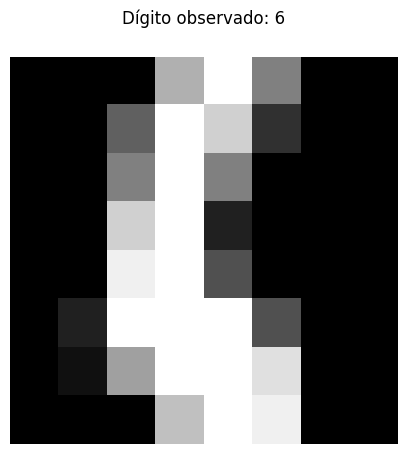

In [2]:
digits = load_digits()
X = digits.data
y = digits.target

print('Dimensión de X:', X.shape)
print('Dimensión de y:', y.shape)
print('Clases:', np.unique(y))

indice = 95
plt.gray()
plt.matshow(digits.images[indice])
plt.title(f'Dígito observado: {y[indice]}')
plt.axis('off')
plt.show()

## Separación de entrenamiento y prueba

Dividimos el conjunto de datos en una fracción para entrenamiento y otra para prueba. Esto permite medir la capacidad de generalización del modelo sobre datos no vistos durante el ajuste.

## Árbol de decisión como referencia

Antes de entrenar el bosque aleatorio, conviene comparar con un árbol de decisión individual. Este modelo suele tener alta varianza y puede sobreajustar el conjunto de entrenamiento.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Tamaño entrenamiento:', X_train.shape)
print('Tamaño prueba:', X_test.shape)
print('Distribución entrenamiento:', np.bincount(y_train))
print('Distribución prueba:', np.bincount(y_test))

# Árbol de decisión como referencia
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

print(f'Accuracy del árbol de decisión: {acc_tree:.4f}')
print()
print(classification_report(y_test, y_pred_tree))

Tamaño entrenamiento: (1437, 64)
Tamaño prueba: (360, 64)
Distribución entrenamiento: [142 146 142 146 145 145 145 143 139 144]
Distribución prueba: [36 36 35 37 36 37 36 36 35 36]
Accuracy del árbol de decisión: 0.8250

              precision    recall  f1-score   support

           0       0.92      0.97      0.95        36
           1       0.84      0.72      0.78        36
           2       0.78      0.80      0.79        35
           3       0.79      0.81      0.80        37
           4       0.86      0.86      0.86        36
           5       0.88      0.95      0.91        37
           6       0.81      0.83      0.82        36
           7       0.84      0.86      0.85        36
           8       0.71      0.69      0.70        35
           9       0.82      0.75      0.78        36

    accuracy                           0.82       360
   macro avg       0.82      0.82      0.82       360
weighted avg       0.82      0.82      0.82       360



## Random forest base

Ahora entrenamos un bosque aleatorio con valores iniciales razonables de hiperparámetros. La combinación de múltiples árboles suele producir una frontera de decisión más estable que la de un único árbol.

## Matriz de confusión

La matriz de confusión permite ver en qué clases se equivoca más el modelo. En clasificación multiclase es útil para identificar dígitos que comparten rasgos visuales parecidos.

Accuracy del random forest: 0.9639

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      0.97      0.95        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



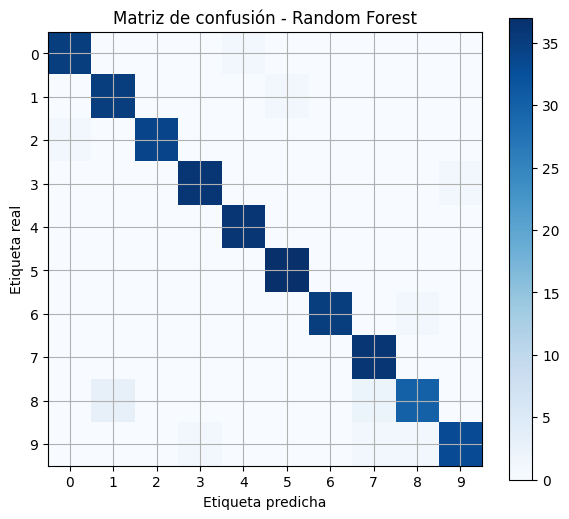

In [4]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Accuracy del random forest: {acc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusión - Random Forest')
plt.xlabel('Etiqueta predicha')
plt.ylabel('Etiqueta real')
plt.colorbar()
plt.xticks(np.arange(10))
plt.yticks(np.arange(10))
plt.show()

## Validación cruzada e importancia de variables

Para obtener una estimación más robusta del rendimiento, calculamos validación cruzada con varios pliegues. Esto ayuda a verificar que el modelo no dependa demasiado de una sola partición entrenamiento-prueba.

Una ventaja del random forest es que permite estimar la importancia relativa de los atributos. En este problema cada atributo corresponde a un píxel de la imagen, por lo que la importancia indica qué regiones influyen más en la clasificación.

Accuracy por pliegue: [0.9333 0.9167 0.9554 0.9721 0.9276]
Accuracy media: 0.9410
Desviación estándar: 0.0200


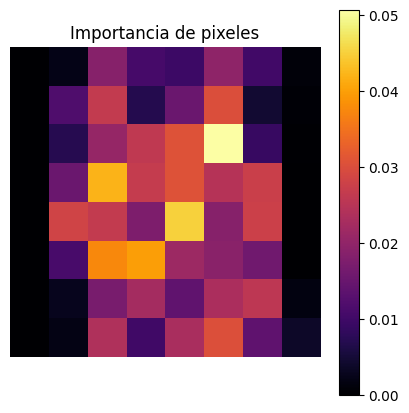

Pixeles más importantes:
Pixel 21 -> importancia 0.0507
Pixel 36 -> importancia 0.0451
Pixel 26 -> importancia 0.0421
Pixel 43 -> importancia 0.0399
Pixel 42 -> importancia 0.0375
Pixel 20 -> importancia 0.0307
Pixel 28 -> importancia 0.0305
Pixel 61 -> importancia 0.0302
Pixel 13 -> importancia 0.0300
Pixel 33 -> importancia 0.0283


In [5]:
scores = cross_val_score(rf_clf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print('Accuracy por pliegue:', np.round(scores, 4))
print(f'Accuracy media: {scores.mean():.4f}')
print(f'Desviación estándar: {scores.std():.4f}')

importances = rf_clf.feature_importances_
importances_img = importances.reshape(8, 8)

plt.figure(figsize=(5, 5))
plt.imshow(importances_img, cmap='inferno')
plt.title('Importancia de pixeles')
plt.colorbar()
plt.axis('off')
plt.show()

top_indices = np.argsort(importances)[::-1][:10]
print('Pixeles más importantes:')
for idx in top_indices:
    print(f'Pixel {idx:02d} -> importancia {importances[idx]:.4f}')

## Ajuste de hiperparámetros

Para explorar el comportamiento del modelo, probamos una búsqueda en malla sobre dos hiperparámetros clave: el número de árboles y la cantidad máxima de características consideradas en cada división.

## Comparación final

Comparamos el árbol de decisión y el random forest con los hiperparámetros óptimos encontrados. La expectativa teórica es que el bosque obtenga un desempeño más estable y, por lo general, superior al del árbol individual.

## Interpretación final

El random forest mejora al árbol de decisión porque reduce la varianza mediante el promedio de muchos árboles entrenados con aleatoriedad controlada. El bootstrap introduce diversidad entre modelos y la selección aleatoria de atributos evita que todos los árboles sigan exactamente las mismas particiones.

En este problema, la importancia de pixeles muestra que no todas las regiones de la imagen contribuyen igual a la clasificación. Los bordes y zonas centrales de los dígitos suelen aportar más información que regiones de fondo.

En resumen, el random forest es una estrategia robusta cuando se busca mejorar generalización sin perder completamente la interpretabilidad local de los árboles de decisión.

Mejores hiperparámetros:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Mejor accuracy de validación: 0.9715
Accuracy árbol de decisión: 0.8250
Accuracy random forest base: 0.9639
Accuracy random forest ajustado: 0.9611


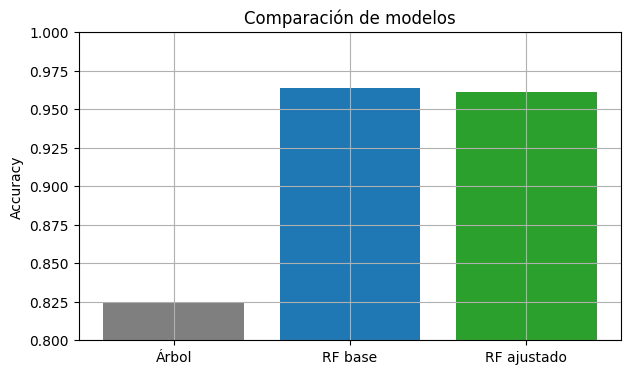

In [6]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Mejores hiperparámetros:')
print(grid_search.best_params_)
print(f'Mejor accuracy de validación: {grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

print(f'Accuracy árbol de decisión: {acc_tree:.4f}')
print(f'Accuracy random forest base: {acc_rf:.4f}')
print(f'Accuracy random forest ajustado: {acc_best:.4f}')

plt.figure(figsize=(7, 4))
modelos = ['Árbol', 'RF base', 'RF ajustado']
valores = [acc_tree, acc_rf, acc_best]
plt.bar(modelos, valores, color=['tab:gray', 'tab:blue', 'tab:green'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Comparación de modelos')
plt.show()